# Materials-to-configuration consequences in modular thermal storage

## tl;dr

Completed simulations support three distinct findings. First, 24 supplementary
energy-controlled services are predicted correctly from previously saved
single-module flow responses on both 2048- and 4096-cell grids. Linear interpolation
also gives the same module decisions. Second, all 208 cross-material reduced-count
classifications agree between grids, including 42 feasible replacements with
8.28–20.70% higher qualified energy than the original fluid. By contrast, all 52
same-material one-module boundary tests change classification. Third, the 120
temperature/loss scenarios comprise 84 feasible, 24 outside the registered
property domain, and 12 infeasible within the tested integer domain. Strong losses
can make installed qualified energy decrease as modules are added.

This notebook is an executed scientific review companion, **not final publication
acceptance**. Failed, infeasible and numerically sensitive outcomes are retained.

## Context & Methods

The question is when fluid-property differences change a modular configuration,
not merely a property ranking. The arithmetic audit imports no production search
or prediction helpers. Simulations share the thermal solver and are not experimental
validation or an independent physical model.

### Key Assumptions

- Power constrains nominal module rating. Energy and outlet temperature constrain
  useful delivery; the model does not guarantee constant instantaneous output power.
- The service tests predict new power–energy requirements using curves already
  computed for the same four seeded geometries. No unseen-geometry extrapolation
  accuracy is claimed. Scale-4 geometries remain model-domain extrapolations.
- The additional 30/60 h tests were specified after discovering a coverage gap.
  Predictions were persisted before reference computations, not externally
  preregistered before the original study.
- Material replacements change only the fluid model, at matched geometry, nominal
  rating and reduced module count. Chemistry, freezing, wetting and corrosion are
  not experimentally qualified.
- The refined configuration reference was previously found by binary search and
  adjacent checks. That historical reference is not globally enumerated here.
- Grid tolerance acceptance, exact integer stability and stability of an
  objective-resolution shortlist are separate statements.
- Temperature and loss scenarios are deterministic model assessments, not sampled
  probabilities. Domain-unsupported cases are neither feasible nor globally infeasible.

## Data

Source records, CSVs and SHA256 manifests are preserved in the independent work
package. Independent signed-energy arithmetic covers 750 new integer evaluations,
including 228 nonpositive cold-reference inventories. Historical migrated no-loss
cases lack these new raw fields. Stage07 search histories retain energy and grade
but not intermediate raw pressure/conservation fields; final pressure is checked.
Eight prespecified 4096-cell boundary replays additionally retain raw pressure,
temperature and conservation outputs and reproduce the selected N and N-1
decisions. This is sampled same-kernel verification, not all-case raw replay.


In [1]:
from pathlib import Path
import json,hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
analysis = Path.cwd()
package = analysis.parent
data = package/'upstream_package/results_upgrade_20261006'
review = analysis/'verified_complete_results'
summary = json.loads((review/'COMPLETE_ARITHMETIC_AUDIT_SUMMARY.json').read_text())
assert summary['failed_checks']==0
replay=json.loads((review/'fine_boundary_replay/REPLAY_SUMMARY.json').read_text())
assert replay['sampled_runs']==8 and all(replay[k] for k in
 ['all_stored_boundaries_matched','all_conservation_accepted','all_property_domains_supported'])
for path in (review/'fine_boundary_replay').glob('*.json'):
    if path.name=='REPLAY_SUMMARY.json':continue
    record=json.loads(path.read_text())
    digest=hashlib.sha256(json.dumps(record['result'],sort_keys=True,allow_nan=False).encode()).hexdigest()
    assert record['identity']==replay['identity'] and record['digest']==digest,path.name
for relative,digest in json.loads((review/'SOURCE_MANIFEST.json').read_text()).items():
    assert hashlib.sha256((package/relative).read_bytes()).hexdigest()==digest,relative
confirm = pd.read_csv(review/'independent_high_energy_confirmation.csv')
stress = pd.read_csv(data/'05_configuration_model_stress.csv')
targets = pd.read_csv(review/'independent_refined_inverse_targets.csv')
replacements = pd.read_csv(review/'independent_refined_material_grid_comparison.csv')
signed = pd.read_csv(review/'independent_signed_inventory_audit.csv')
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':11,'axes.spines.top':False,
 'axes.spines.right':False,'figure.dpi':140})
blue,gold,rose,gray = '#276C8E','#BF862F','#9C586D','#767676'
print('Saved source hashes verified. This notebook does not execute thermal simulations.')


Saved source hashes verified. This notebook does not execute thermal simulations.


## Results

### 1. Energy-controlled service prediction

Sources: saved prior curves, prediction commitment, and all 48 supplementary
fine-grid enumerations. Each reference search starts at the rating lower bound and
tests every integer through its first feasible count. All 24 cases are genuinely
energy controlled, and all reference counts agree across the two fine grids.


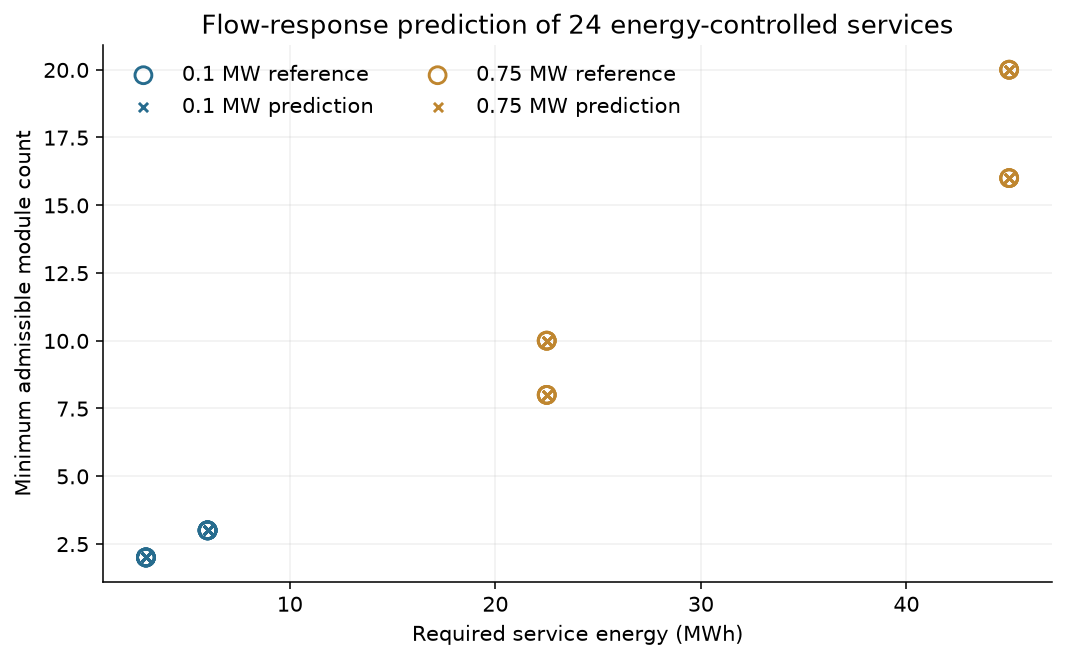

,Cases,Exact_matches,Maximum_absolute_count_error
n_cells,,,
2048,24,24,0
4096,24,24,0


In [2]:
fine = confirm[confirm.n_cells==4096].copy()
fine['required_energy_MWh']=fine.power_MW*fine.energy_to_power_h
fig,ax = plt.subplots(figsize=(7.5,4.6),layout='constrained')
for p,color in [(0.1,blue),(0.75,gold)]:
    rows=fine[fine.power_MW.eq(p)]
    ax.scatter(rows.required_energy_MWh,rows.observed_count,s=75,facecolors='none',
               edgecolors=color,linewidths=1.5,label=f'{p:g} MW reference')
    ax.scatter(rows.required_energy_MWh,rows.predicted_count,s=22,marker='x',
               color=color,label=f'{p:g} MW prediction')
ax.set(xlabel='Required service energy (MWh)',ylabel='Minimum admissible module count',
 title='Flow-response prediction of 24 energy-controlled services')
ax.legend(loc='upper left',frameon=False,ncol=2)
ax.set_axisbelow(True);ax.grid(alpha=.18)
plt.show()
display(confirm.groupby('n_cells').agg(Cases=('count_error','size'),
 Exact_matches=('count_error',lambda s:int(s.eq(0).sum())),
 Maximum_absolute_count_error=('count_error',lambda s:int(s.abs().max()))))


The plot deliberately overlays matching predictions and reference counts.
Count accuracy is 24/24 on each grid. The finite test also yields 24/24 agreement
for linear interpolation, so it supports transfer to new services at known
geometries, not superiority of a particular interpolation algorithm.

### 2. Material replacement versus a numerical integer boundary

Source: all 260 paired replacements relative to the 52 refined configurations.
Each panel uses the same required service energy as its denominator. Positive
margins satisfy the energy requirement; pressure and outlet-grade gates are
checked independently. Cross-material replacements and same-material controls
must not be pooled into a single robustness claim.


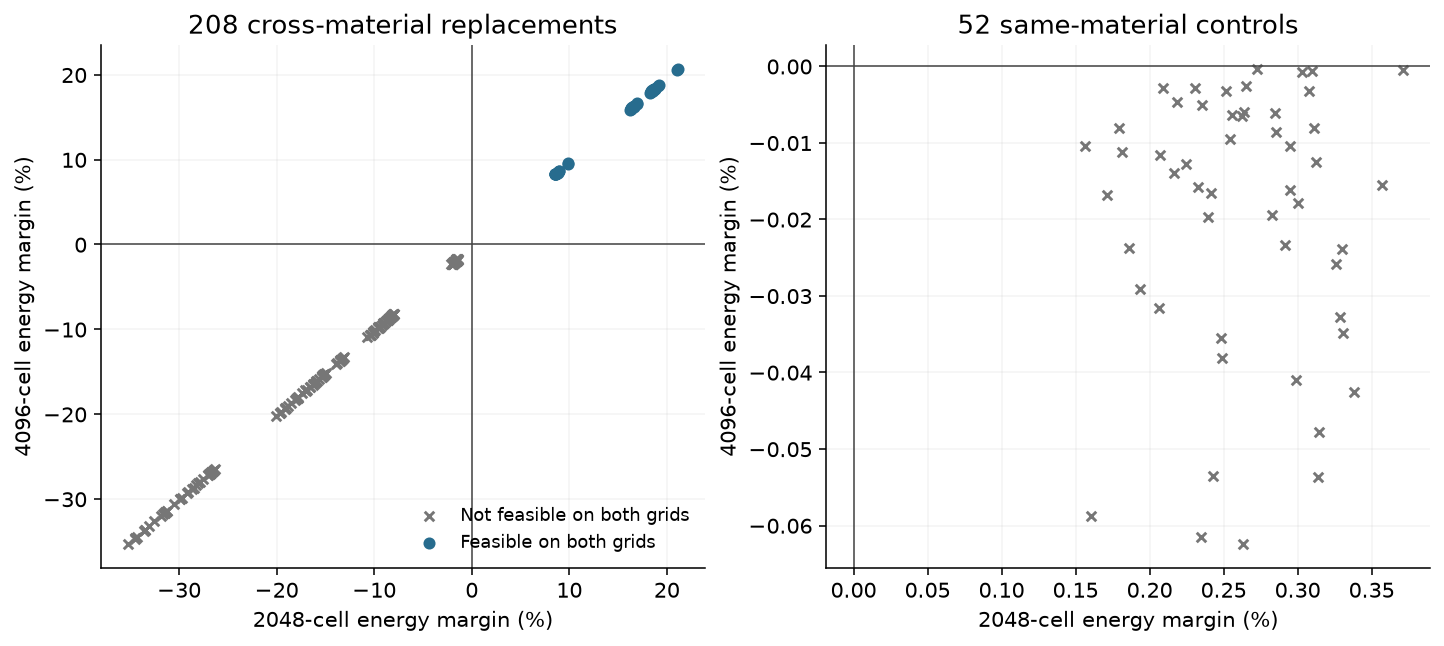

,Comparison,Paired cases,Classification changes,Feasible on both grids
0,Different fluid,208,0,42
1,Same fluid,52,52,0


In [3]:
cross = replacements[~replacements.same_material].copy()
self_tests = replacements[replacements.same_material].copy()
fig,axes=plt.subplots(1,2,figsize=(10.2,4.5),layout='constrained')
for ax,rows,title in [(axes[0],cross,'208 cross-material replacements'),
                      (axes[1],self_tests,'52 same-material controls')]:
    demands = targets[targets.n_cells.eq(4096)][['design_id','service_id','required_energy_MWh']]
    rows=rows.merge(demands,left_on=['case_design_id','service_id'],right_on=['design_id','service_id'],validate='many_to_one')
    x=100*(rows.installed_energy_MWh_2048/rows.required_energy_MWh-1)
    y=100*(rows.installed_energy_MWh_4096/rows.required_energy_MWh-1)
    stable=rows.reduced_count_feasible_2048&rows.reduced_count_feasible_4096
    ax.scatter(x[~stable],y[~stable],s=24,color=gray,marker='x',label='Not feasible on both grids')
    ax.scatter(x[stable],y[stable],s=27,color=blue,label='Feasible on both grids')
    ax.axhline(0,color='#454545',linewidth=.8);ax.axvline(0,color='#454545',linewidth=.8)
    ax.set(title=title,xlabel='2048-cell energy margin (%)',ylabel='4096-cell energy margin (%)')
    ax.set_axisbelow(True);ax.grid(alpha=.14)
axes[0].legend(loc='lower right',frameon=False,fontsize=9)
plt.show()
display(pd.DataFrame({'Comparison':['Different fluid','Same fluid'],
 'Paired cases':[len(cross),len(self_tests)],
 'Classification changes':[int(cross.feasibility_changed.sum()),int(self_tests.feasibility_changed.sum())],
 'Feasible on both grids':[int((cross.reduced_count_feasible_2048&cross.reduced_count_feasible_4096).sum()),
                         int((self_tests.reduced_count_feasible_2048&self_tests.reduced_count_feasible_4096).sum())]}))


The two panels intentionally have separate scales because the control margins
are much smaller. All 208 cross-material classifications agree, with 42 feasible
replacements. All 52 same-material controls are feasible at 2048 cells but not at
4096 cells. The refined median required gain of 0.014715% is therefore a
grid-conditioned boundary, not a numerically stable material-improvement target.

### 3. Magnitude of robust cross-material effects

Source: all cross-material pairs, retaining both successful and unsuccessful
replacements. Gains compare qualified installed energy with the original fluid at
the same count and flow-resolved nominal service power.


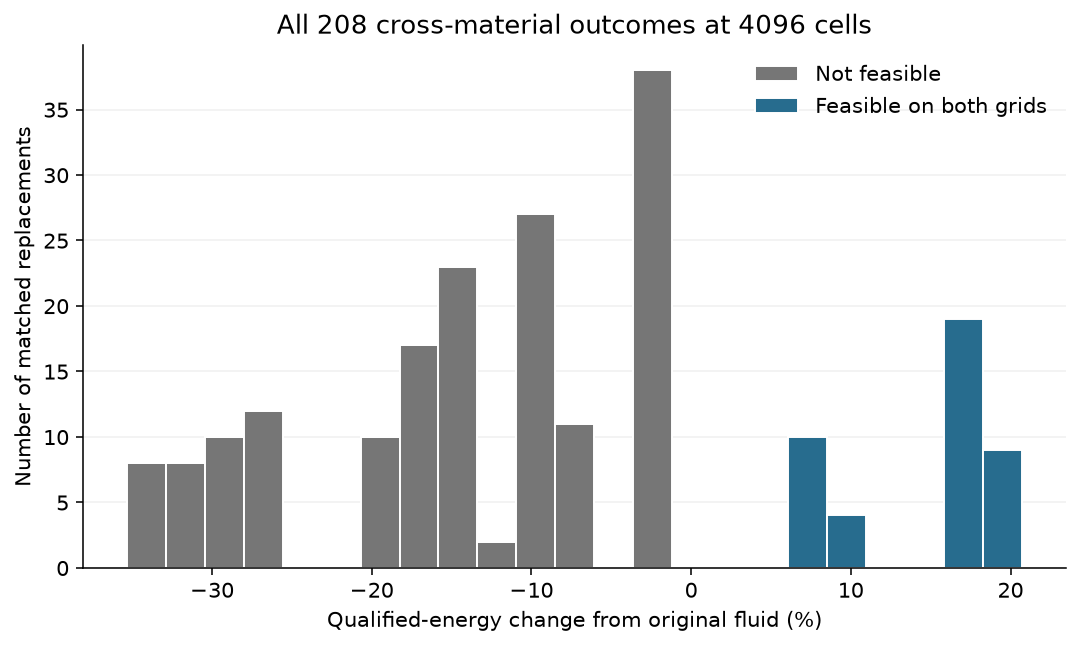

Robust feasible cross-material gains: 8.28 to 20.7 % in 42 pairs.


In [4]:
fig,ax=plt.subplots(figsize=(7.6,4.5),layout='constrained')
success=cross.reduced_count_feasible_2048&cross.reduced_count_feasible_4096
bins=np.linspace(min(cross.relative_energy_change_pct_4096.min(),-1),
                 max(cross.relative_energy_change_pct_4096.max(),1),24)
ax.hist([cross.loc[~success,'relative_energy_change_pct_4096'],
         cross.loc[success,'relative_energy_change_pct_4096']],bins=bins,stacked=True,
         color=[gray,blue],edgecolor='white',label=['Not feasible','Feasible on both grids'])
ax.set(xlabel='Qualified-energy change from original fluid (%)',ylabel='Number of matched replacements',
 title='All 208 cross-material outcomes at 4096 cells')
ax.legend(frameon=False);ax.set_axisbelow(True);ax.grid(axis='y',alpha=.18)
plt.show()
print('Robust feasible cross-material gains:',round(cross.loc[success,'relative_energy_change_pct_4096'].min(),2),
 'to',round(cross.loc[success,'relative_energy_change_pct_4096'].max(),2),'% in',int(success.sum()),'pairs.')


The 42 feasible cross-material replacements gain 8.28–20.70% in qualified
energy, exceeding the maximum paired grid energy difference of 0.407%. This
comparison is conditional numerical evidence, not a guarantee of deployment or
material compatibility. A zero ideal-inventory necessary bound is not sufficient
to meet the transient qualified-energy requirement.

### 4. Temperature treatment and heat-loss outcomes

Source: all 120 matched model scenarios, including domain-unsupported and
infeasible cases. Each scenario comprises 24 services for Solar Salt and FLiNaK,
three arrangements, two powers and two energy requirements.


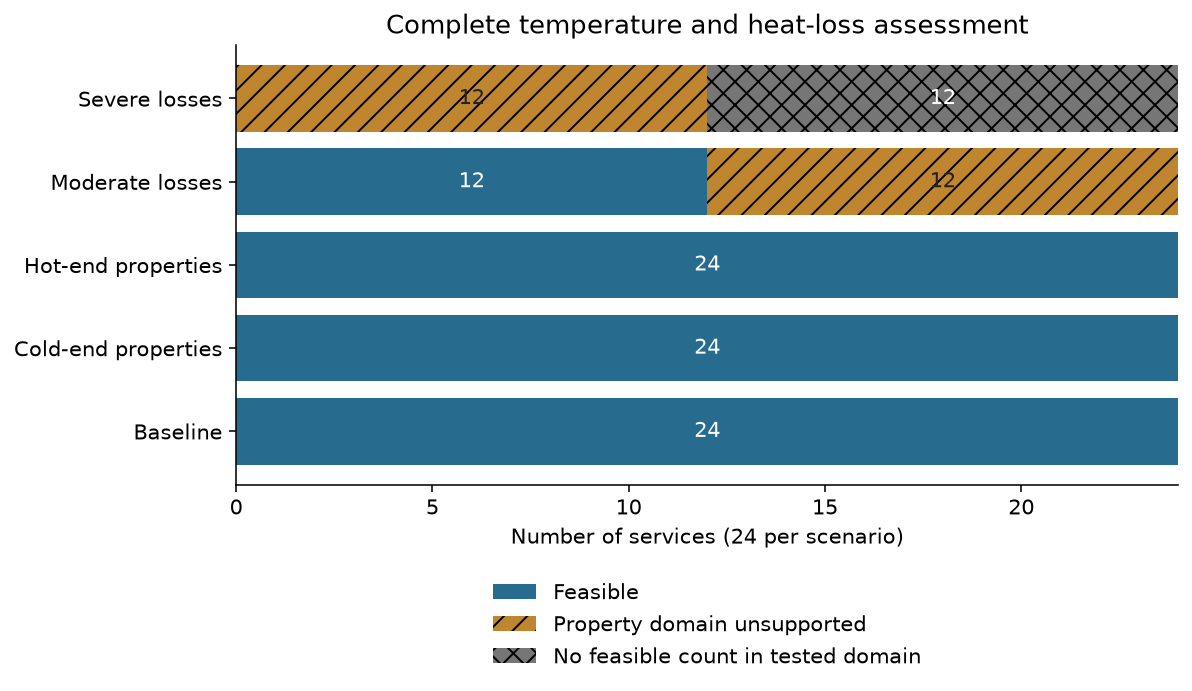

Cases
scenario_id                 fluid_model_id       status                                       
baseline                    AIP_FLINAK_2017_V10  FEASIBLE                                   12
                            SOLAR_SALT_60_40_V10 FEASIBLE                                   12
properties_at_cold_endpoint AIP_FLINAK_2017_V10  FEASIBLE                                   12
                            SOLAR_SALT_60_40_V10 FEASIBLE                                   12
properties_at_hot_endpoint  AIP_FLINAK_2017_V10  FEASIBLE                                   12
                            SOLAR_SALT_60_40_V10 FEASIBLE                                   12
registered_moderate_losses  AIP_FLINAK_2017_V10  MODEL_DOMAIN_UNSUPPORTED                   12
                            SOLAR_SALT_60_40_V10 FEASIBLE                                   12
registered_severe_losses    AIP_FLINAK_2017_V10  MODEL_DOMAIN_UNSUPPORTED                   12
                            SOLAR_SALT_60_40_V10 NO_FEASIBLE_COUNT_IN_REGISTERED_DOMAIN     12

In [5]:
scenario_order=['baseline','properties_at_cold_endpoint','properties_at_hot_endpoint',
                'registered_moderate_losses','registered_severe_losses']
outcomes=stress.groupby(['scenario_id','status']).size().unstack(fill_value=0).reindex(scenario_order)
columns=['FEASIBLE','MODEL_DOMAIN_UNSUPPORTED','NO_FEASIBLE_COUNT_IN_REGISTERED_DOMAIN']
outcomes=outcomes.reindex(columns=columns,fill_value=0)
fig,ax=plt.subplots(figsize=(8.4,4.8),layout='constrained')
left=np.zeros(5)
for status,color,hatch,label in zip(columns,[blue,gold,gray],['','//','xx'],
 ['Feasible','Property domain unsupported','No feasible count in tested domain']):
    values=outcomes[status].to_numpy()
    ax.barh(np.arange(5),values,left=left,color=color,hatch=hatch,label=label)
    for i,(value,start) in enumerate(zip(values,left)):
        if value:ax.text(start+value/2,i,str(int(value)),ha='center',va='center',color='white' if color!=gold else '#222222')
    left+=values
ax.set(yticks=np.arange(5),yticklabels=['Baseline','Cold-end properties','Hot-end properties','Moderate losses','Severe losses'],
 xlabel='Number of services (24 per scenario)',xlim=(0,24),title='Complete temperature and heat-loss assessment')
ax.legend(loc='upper center',bbox_to_anchor=(.5,-.18),frameon=False,ncol=1)
plt.show()
display(stress.groupby(['scenario_id','fluid_model_id','status']).size().rename('Cases').to_frame())


All 72 no-loss temperature-evaluation cases are feasible. Moderate losses leave
the 12 Solar Salt cases feasible; the 12 FLiNaK cases cross its registered property
window. Severe losses yield 12 Solar Salt cases without a feasible count over the
complete tested integer domain and 12 unsupported FLiNaK cases. Unsupported
FLiNaK cases do not establish global infeasibility or physically validated cooling.

### 5. Why adding modules can cease to improve delivery

Source: complete severe-loss enumeration histories at 0.1 MW and 0.75 h for
Solar Salt. These curves retain every tested count. Increasing count lowers flow
through each parallel module while increasing total vessel surface area. The
result is conditional on the prescribed deterministic loss model.


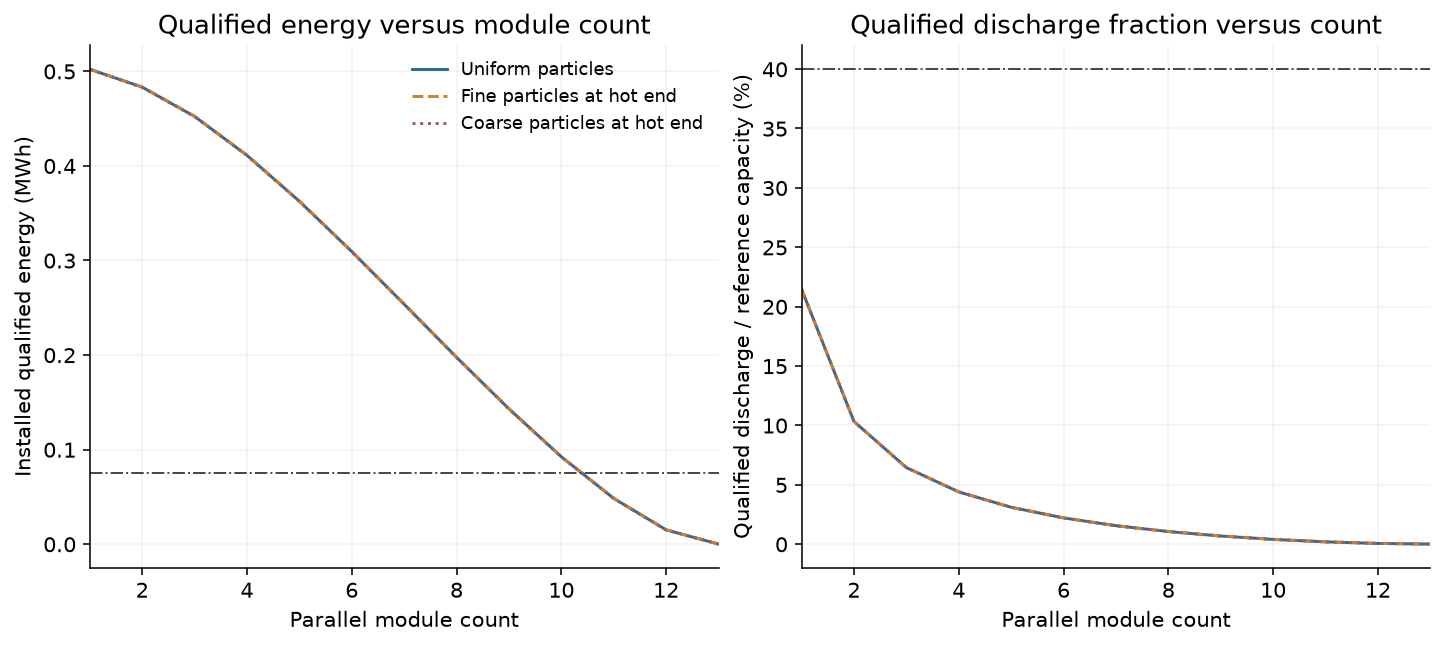

In [6]:
checkpoint_dir=package/'upstream_package/.upgrade_checkpoints_20261006/05_signed_configuration_model_stress'
records=[json.loads(p.read_text())['result'] for p in checkpoint_dir.glob('*.json')]
chosen=[r for r in records if r['scenario_id']=='registered_severe_losses'
        and r['fluid_model_id']=='SOLAR_SALT_60_40_V10' and r['power_MW']==.1 and r['energy_to_power_h']==.75]
assert len(chosen)==3
fig,axes=plt.subplots(1,2,figsize=(10.2,4.5),layout='constrained')
names={'T1_homogeneous_none':'Uniform particles','T2_graded_two_layer_fine_hot':'Fine particles at hot end',
       'T3_graded_two_layer_coarse_hot':'Coarse particles at hot end'}
for row,color,style in zip(sorted(chosen,key=lambda r:r['topology_id']),[blue,gold,rose],['-','--',':']):
    t=pd.DataFrame(row['trajectory'])
    axes[0].plot(t['count'],t.installed_energy_MWh,color=color,linestyle=style,label=names[row['topology_id']])
    axes[1].plot(t['count'],100*t.high_grade_discharge_fraction,color=color,linestyle=style)
axes[0].axhline(.075,color='#444444',linestyle='-.',linewidth=1)
axes[1].axhline(40,color='#444444',linestyle='-.',linewidth=1)
axes[0].set(ylabel='Installed qualified energy (MWh)',title='Qualified energy versus module count')
axes[1].set(ylabel='Qualified discharge / reference capacity (%)',title='Qualified discharge fraction versus count')
for ax in axes:ax.set(xlabel='Parallel module count',xlim=(1,13));ax.grid(alpha=.16)
axes[0].legend(loc='upper right',frameon=False,fontsize=9)
plt.show()


Even where energy demand alone is initially satisfied, the minimum qualified
discharge fraction is not met. Installed qualified energy subsequently declines
with count. This shows why rating, energy and outlet-quality constraints must be
applied jointly, and why monotonic feasibility cannot be assumed under losses.
It does not imply that all storage systems behave this way.

### 6. Signed energy accounting

Source: independently recomputed discharge residuals for all 750 new stored
integer evaluations. Energy is relative to the cold reference; a negative value
does not mean negative absolute internal energy. The correction preserves signs
in the balance instead of dividing by a positive epsilon.


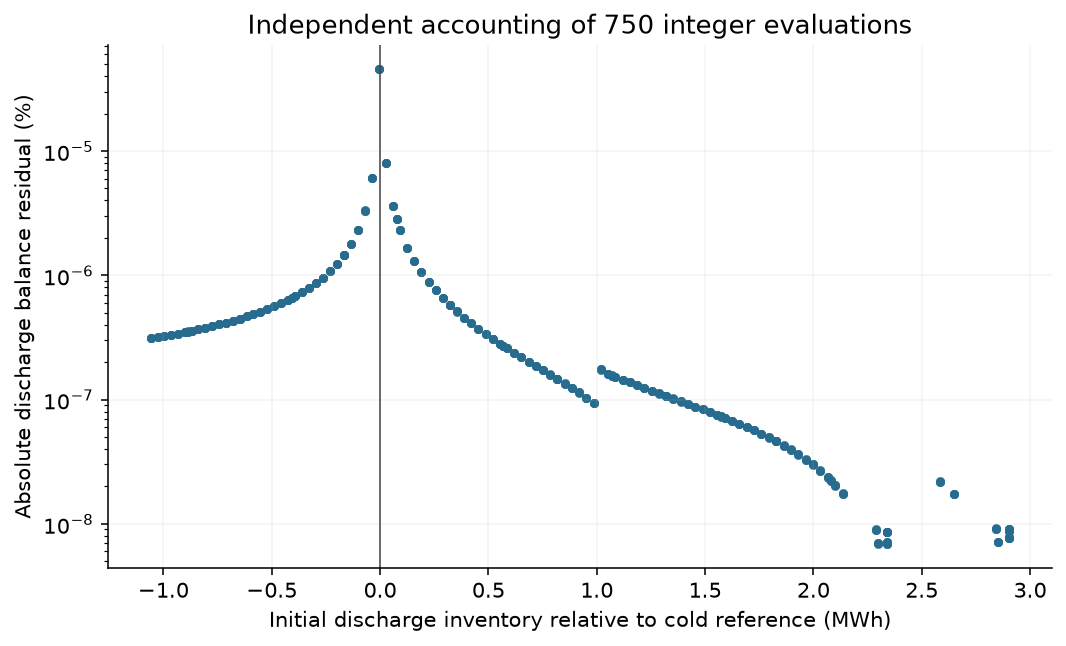

Largest absolute discharge balance error: 4.56908492686332e-05 %
Prescribed conservation threshold: 0.1%; nonpositive reference inventories: 228


In [7]:
fig,ax=plt.subplots(figsize=(7.5,4.5),layout='constrained')
ax.scatter(signed.initial_reference_inventory_J/3.6e9,
           signed.independent_discharge_error_pct.abs(),s=13,color=blue,alpha=.55)
ax.set(yscale='log',xlabel='Initial discharge inventory relative to cold reference (MWh)',
       ylabel='Absolute discharge balance residual (%)',title='Independent accounting of 750 integer evaluations')
ax.axvline(0,color='#454545',linewidth=.8);ax.grid(alpha=.14)
plt.show()
print('Largest absolute discharge balance error:',summary['maximum_signed_discharge_error_pct'],'%')
print('Prescribed conservation threshold: 0.1%; nonpositive reference inventories:',
      summary['negative_reference_inventory_evaluations'])


The largest discharge residual is 0.0000457%, below the unchanged 0.1% gate.
This verifies output accounting, not temperature-dependent chemistry or a second
thermal model. No numerical threshold was relaxed to rescue the adverse cases.

## Takeaways

1. Prior flow responses predict all 24 additional energy-controlled service counts
   on both fine grids, within the tested known-geometry model domain.
2. Cross-material changes with substantial qualified-energy margins are stable;
   single-module same-material boundaries are not grid invariant.
3. Strong losses create nonmonotone installed-energy response and can remove
   outlet-qualified feasibility. Property-domain failures remain unresolved.
4. These findings narrow the scientific contribution to propagation of material
   effects, coupled flow/sizing, numerical decision resolution, and explicit model
   applicability. They do not validate every material or every operating service.
5. Final figures, manuscripts, source references and Word page layouts still
   require synchronization and complete verification. The existing DOI archives
   the baseline only, not these new unpublished calculations.

## Reproduction

Run `analysis/audit_final_computation.py` with the locked E:/Python311 scientific
runtime. Run this notebook builder with the isolated notebook presentation runtime.
No thermal simulations execute during these two analysis steps. Intermediate review
figures are not submission files. Full HTML-viewer inspection remains unavailable
because the browser rejects local file URLs; inspect saved notebook outputs in a
permitted notebook viewer. Individual rendered PNG figures are inspected separately.
